# Min-Max, Standard & Robust Scaling + Outlier Handling (Clipping, Winsorizing & Bounding)

In [3]:
import seaborn as sns
import numpy as np 
import pandas as pd 
from scipy.stats.mstats import winsorize 
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt

### 1. Generating Synthetic Data


In [6]:
#This means random numbers will be the same every time.
np.random.seed(42)
# This creates 200 random numbers.
feat_1 = np.random.normal(loc=60, scale=6, size=200)
# This is the mean (average). Most values will be near 60.
# Small scale → values close to 60. Large scale → more spread

# This creates right-skewed data.
feat_2 = np.random.exponential(scale=60, size=200)

# 195 values around 15.
f = np.random.normal(loc=15, scale=3, size=195)

# This adds 5 very large values.
feat_3 = np.append(f, [f.max()+50, f.max()+100, f.max()+150, f.max()+200, f.max()+250])
# 50, 55, 60, 58, 1000. 1000 is impossible. That is an outlier.

df = pd.DataFrame({'Normal': feat_1,'Skewed': feat_2,'With_Outliers': feat_3})
df.head()

,Normal,Skewed,With_Outliers
0,62.980285,125.916518,14.673720
1,59.170414,81.002055,16.205135
2,63.886131,71.644466,17.070432
3,69.138179,72.737253,13.796339
4,58.595080,26.729541,15.672277


We create a controlled dataset to illustrate different data challenges:
+ Normal: Symmetric bell shaped distribution (ideal case)
+ Skewed: Right skewed (common in real data like income or time to event)
+ With_Outliers: Mostly normal but contaminated with five extreme values

The reason for including the above three cases is that the real datasets often combine these characteristics. By using the same
data throughout, we can clearly see how each technique responds to normality, skewness, and outliers.

### 2. Visualizing Original Distributions using Boxplots and KDE plots


Boxplots are one of the best tools to understand data distribution because they show:
+ Median (middle line)
+ Interquartile range (box)
+ Whiskers (1.5 × IQR)
+ Individual outliers (points beyond whiskers)


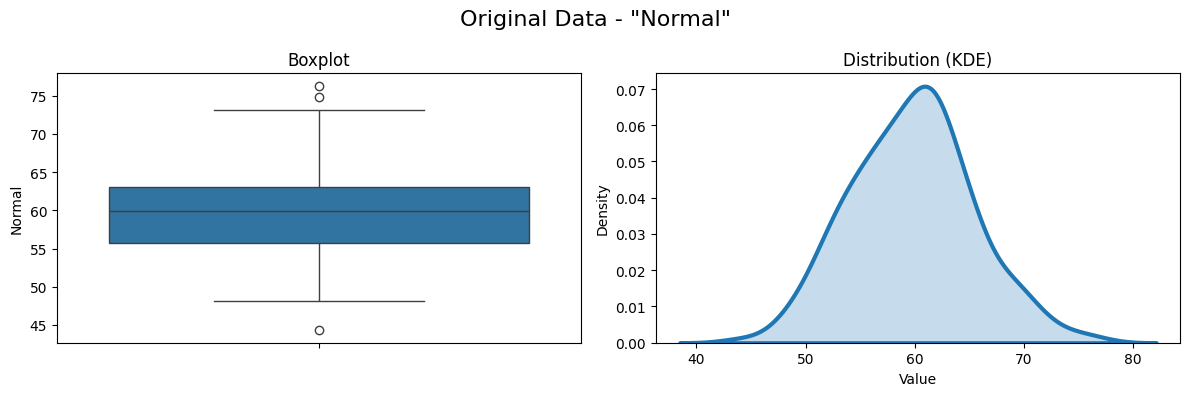

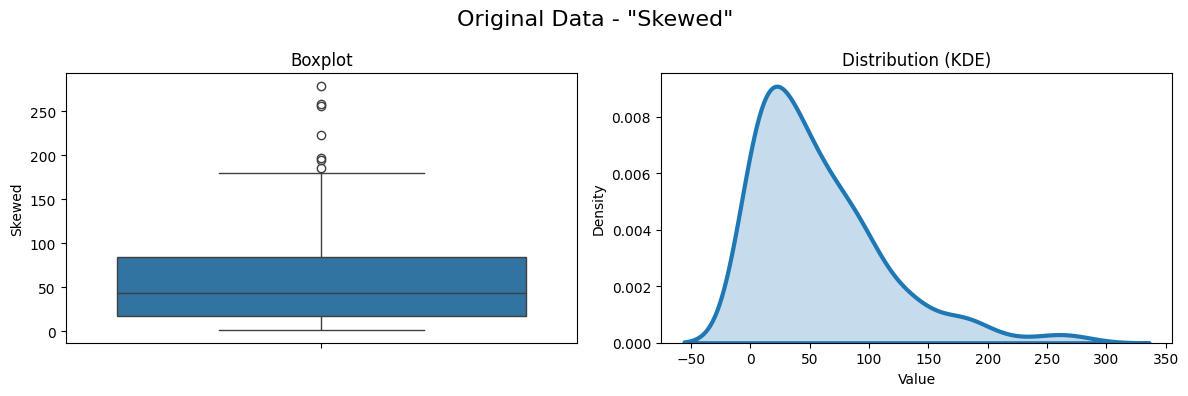

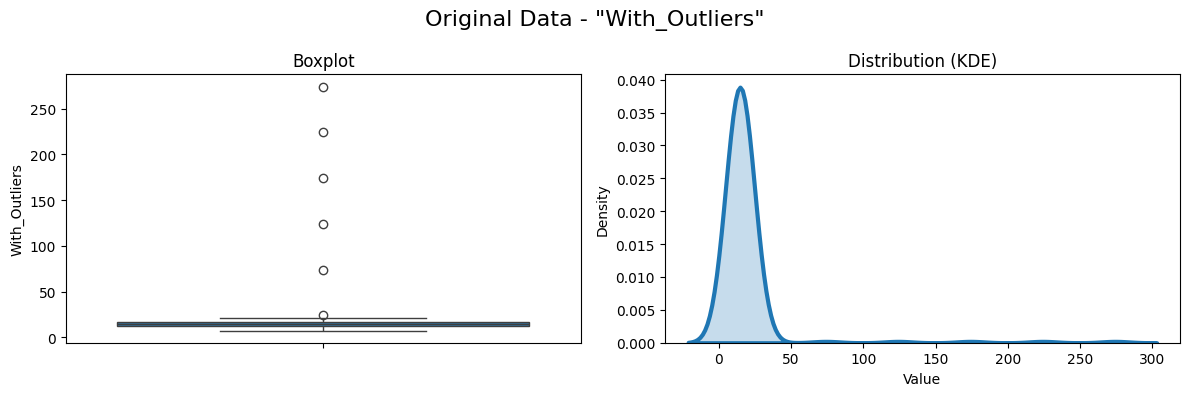

In [ ]:
for col in df.columns:
 fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 fig.suptitle(f'Original Data - "{col}"',fontsize=16)
 sns.boxplot(y=df[col], ax=axes[0])
 axes[0].set_title('Boxplot')
 axes[0].set_ylabel(col)
 sns.kdeplot(df[col], fill=True, linewidth=3, ax=axes[1])
 axes[1].set_title('Distribution (KDE)')
 axes[1].set_xlabel('Value')
 axes[1].set_ylabel('Density')
 plt.tight_layout()
 plt.show()
 
 
# Lower = Q1 - 1.5 × IQR
# Upper = Q3 + 1.5 × IQR
# Any point outside this is often considered an outlier.
# Dots outside whiskers = extreme values.

# KDE - This is a smooth version of histogram.


# 3. Applying Scalers


In [8]:
# Initializing the scalers
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Fit and Transform
minmax_scal = minmax_scaler.fit_transform(df)
standard_scal = standard_scaler.fit_transform(df)
robust_scal = robust_scaler.fit_transform(df)

print(f"Min-Max Scaled Data: {minmax_scal[:2]}\n")
print(f"Standard Scaled Data: {standard_scal[:2]}\n")
print(f"Robust Scaled Data: {robust_scal[:2]}\n")

Min-Max Scaled Data: [[0.58361597 0.44934638 0.02658395]
 [0.46470424 0.28822778 0.03232709]]

Standard Scaled Data: [[ 0.57876651  1.25327389 -0.15071353]
 [-0.10498128  0.4244209  -0.09491881]]

Robust Scaled Data: [[ 0.41535181  1.24126977 -0.04738283]
 [-0.11117299  0.56668602  0.31205043]]



As you can see, the transformed dataset produced by the scaler transformer is in array format. We need to convert it into a
DataFrame so that the visualization step will be easier.


In [9]:
# put the scaled dataset in a dataframe
df_minmax = pd.DataFrame(minmax_scal, columns=df.columns)
df_standard = pd.DataFrame(standard_scal, columns=df.columns)
df_robust = pd.DataFrame(robust_scal, columns=df.columns)

### 4. Visualizing the Scaled Distributions (Boxplot side by side)


### 4.1. Original Distributions


<Axes: title={'center': 'Original distributions'}>

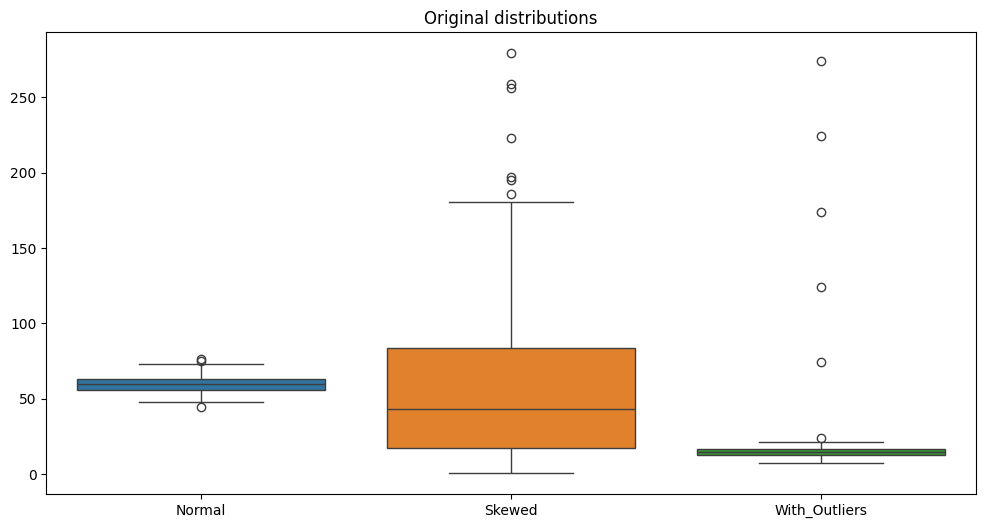

In [10]:
plt.figure(figsize=(12, 6))
plt.title('Original distributions')
sns.boxplot(data=df)

### 4.2. Min-Max scaling


<Axes: title={'center': 'Min-Max Scaled Data'}>

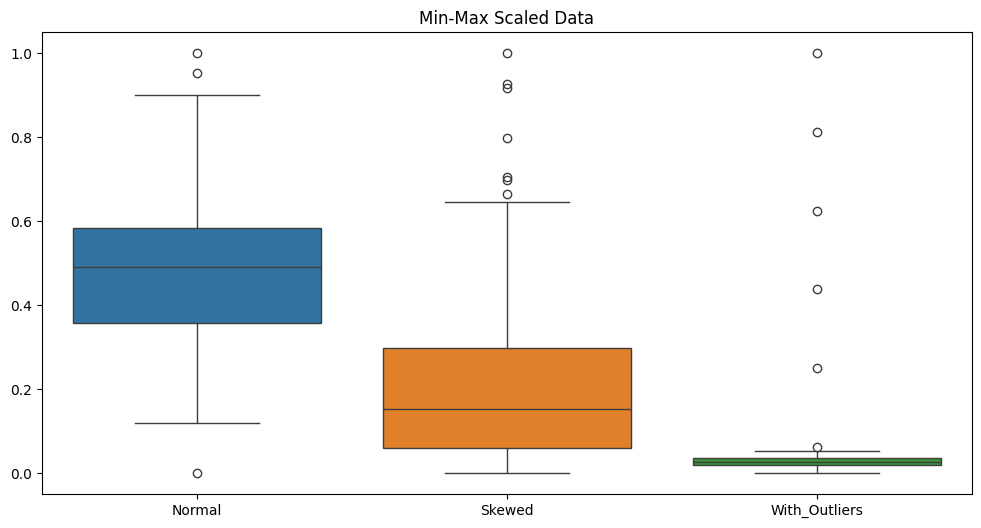

In [11]:
plt.figure(figsize=(12, 6))
plt.title('Min-Max Scaled Data')
sns.boxplot(data=df_minmax)

### 4.3. Standard scaling


<Axes: title={'center': 'Standard Scaled Data'}>

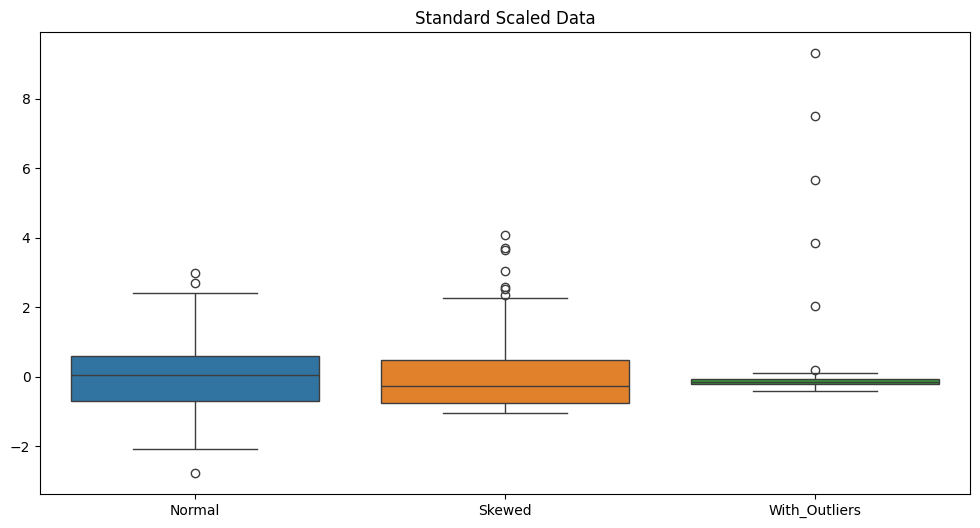

In [12]:
plt.figure(figsize=(12, 6))
plt.title('Standard Scaled Data')
sns.boxplot(data=df_standard)

### 4.4. Robust Scaling


<Axes: title={'center': 'Robust Scaled Data'}>

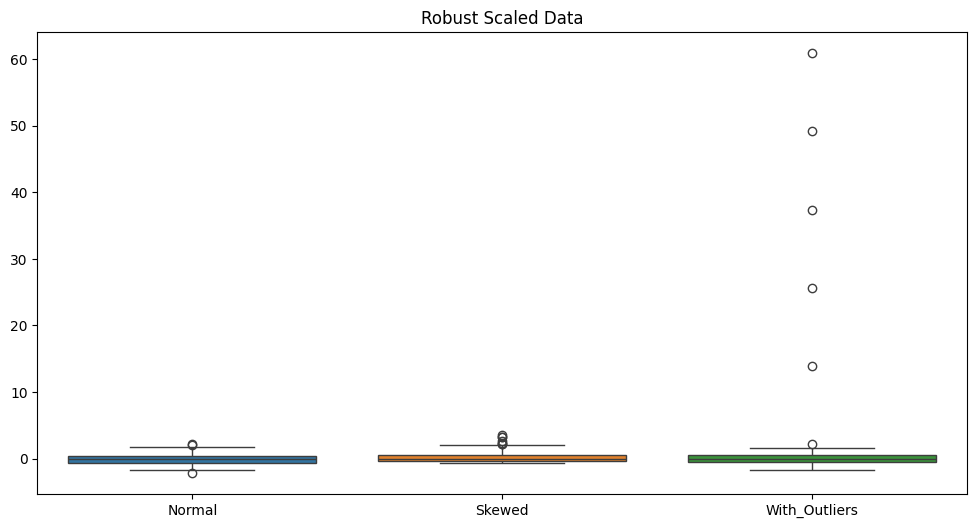

In [13]:
plt.figure(figsize=(12, 6))
plt.title('Robust Scaled Data')
sns.boxplot(data=df_robust, showfliers=True)

<Axes: title={'center': 'Robust Scaled Data'}>

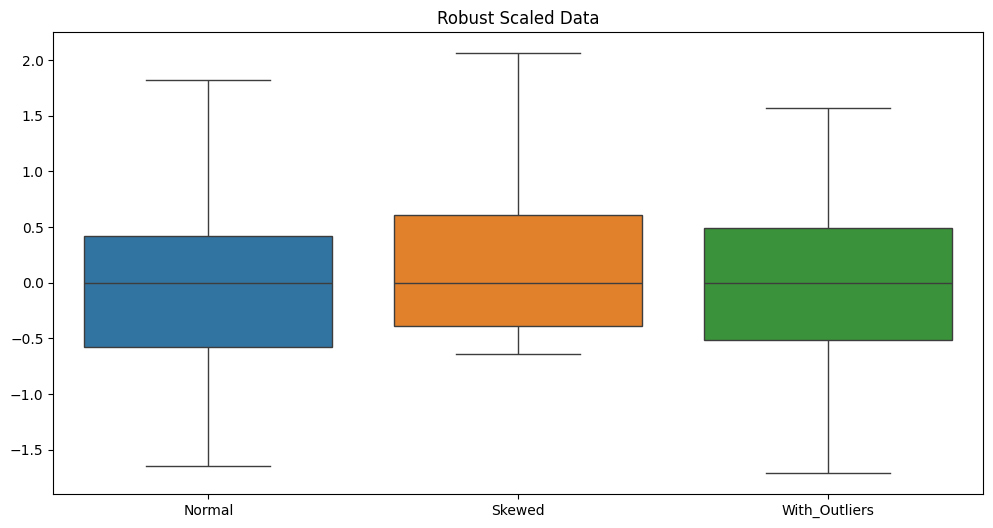

In [14]:
plt.figure(figsize=(12, 6))
plt.title('Robust Scaled Data')
sns.boxplot(data=df_robust, showfliers=False)

+ When showfliers=True , you can see that the original extreme values remain far out (RobustScaler does NOT clip or remove
outliers)
+ When showfliers=False , the main body of data looks beautifully centered at 0 with IQR = 1.

Robust scaling helps keep most of the data well behaved while still keeping outliers as they are. This makes it a safe default choice
for messy, real-world datasets.

It works by using the median (instead of the mean) and the interquartile range (the middle 50% of the data). Because of this, extreme values don’t distort the scale of the majority of the data.

MinMaxScaler Scales to [0, 1]. Outliers compress the normal data into a very narrow range.

StandardScaler Centers at mean = 0, std = 1. Outliers strongly influence mean and std. It distorts the scale of normal points.

### Outlier Handling Techniques (Clipping, Winsorizing & Bounding)
